# Retail Sales Forecasting using Prophet

## Table of Contents

* **Section 1:** Imports
* **Section 2:** Load Dataset
* **Section 3:** Create Daily Sales Time Series
* **Section 4:** Prepare Data for Prophet
* **Section 5:** Train-Test Split
* **Section 6:** Build Prophet Model
* **Section 7:** Generate Forecast
* **Section 8:** Forecast Visualization
* **Section 9:** Trend and Seasonality Analysis
* **Section 10:** Model Evaluation
* **Section 11:** Compare Prophet with Previous Forecasting Models
* **Section 12:** Final Model Ranking
* **Section 13:** Phase 3 Findings

In [1]:
# ============================================================
# SECTION 1: IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

plt.style.use("default")

Importing plotly failed. Interactive plots will not work.


In [2]:
# ============================================================
# SECTION 2: LOAD DATA
# ============================================================

train = pd.read_csv(
    "../data/raw/train.csv",
    low_memory=False
)

train["Date"] = pd.to_datetime(
    train["Date"]
)

print(train.shape)

train.head()

(1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
# ============================================================
# SECTION 3: CREATE DAILY SALES SERIES
# ============================================================

daily_sales = (
    train.groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [4]:
# ============================================================
# SECTION 4: PROPHET FORMAT
# ============================================================

prophet_df = daily_sales.rename(
    columns={
        "Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [5]:
# ============================================================
# SECTION 5: TRAIN TEST SPLIT
# ============================================================

train_size = int(
    len(prophet_df) * 0.90
)

train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

print("Train:", len(train_prophet))
print("Test :", len(test_prophet))

Train: 847
Test : 95


In [6]:
# ============================================================
# SECTION 6: TRAIN PROPHET MODEL
# ============================================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train_prophet)

21:12:48 - cmdstanpy - INFO - Chain [1] start processing
21:12:52 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# ============================================================
# SECTION 7: FORECAST
# ============================================================

future = model.make_future_dataframe(
    periods=len(test_prophet),
    freq="D"
)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,5.969009e+06,4.341304e+06,9.153937e+06,5.969009e+06,5.969009e+06,780971.569282,780971.569282,780971.569282,1.289397e+06,1.289397e+06,1.289397e+06,-508424.940092,-508424.940092,-508424.940092,0.0,0.0,0.0,6.749981e+06
1,2013-01-02,5.970516e+06,3.937989e+06,8.326634e+06,5.970516e+06,5.970516e+06,250075.962598,250075.962598,250075.962598,7.888801e+05,7.888801e+05,7.888801e+05,-538804.168116,-538804.168116,-538804.168116,0.0,0.0,0.0,6.220592e+06
2,2013-01-03,5.972023e+06,3.524689e+06,8.196436e+06,5.972023e+06,5.972023e+06,-22902.759235,-22902.759235,-22902.759235,5.324653e+05,5.324653e+05,5.324653e+05,-555368.023702,-555368.023702,-555368.023702,0.0,0.0,0.0,5.949120e+06
3,2013-01-04,5.973530e+06,4.123976e+06,8.734412e+06,5.973530e+06,5.973530e+06,490290.254609,490290.254609,490290.254609,1.048756e+06,1.048756e+06,1.048756e+06,-558465.553546,-558465.553546,-558465.553546,0.0,0.0,0.0,6.463820e+06
4,2013-01-05,5.975037e+06,3.272646e+06,7.832806e+06,5.975037e+06,5.975037e+06,-457321.784428,-457321.784428,-457321.784428,9.137791e+04,9.137791e+04,9.137791e+04,-548699.697557,-548699.697557,-548699.697557,0.0,0.0,0.0,5.517715e+06


In [8]:
# ============================================================
# SECTION 8: EVALUATION
# ============================================================

predictions = forecast["yhat"].tail(
    len(test_prophet)
).values

actuals = test_prophet["y"].values

mae = mean_absolute_error(
    actuals,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actuals,
        predictions
    )
)

mape = mean_absolute_percentage_error(
    actuals,
    predictions
) * 100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2))

MAE : 1510428.54
RMSE: 2101397.93
MAPE: 107.32


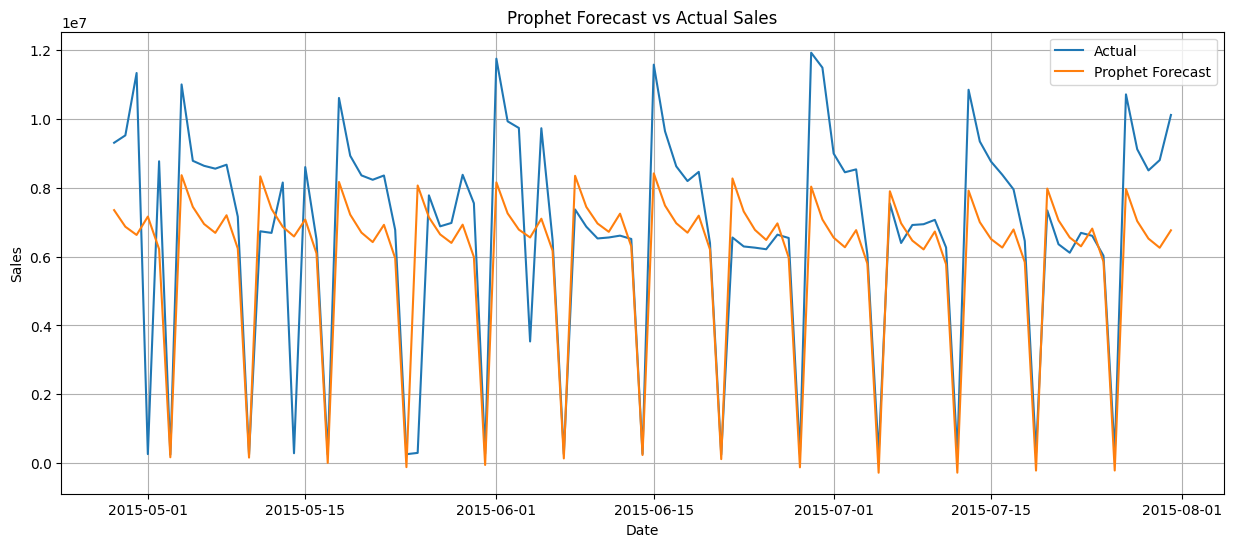

In [9]:
# ============================================================
# SECTION 9: FORECAST PLOT
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    test_prophet["ds"],
    actuals,
    label="Actual"
)

plt.plot(
    test_prophet["ds"],
    predictions,
    label="Prophet Forecast"
)

plt.title(
    "Prophet Forecast vs Actual Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid()

plt.show()

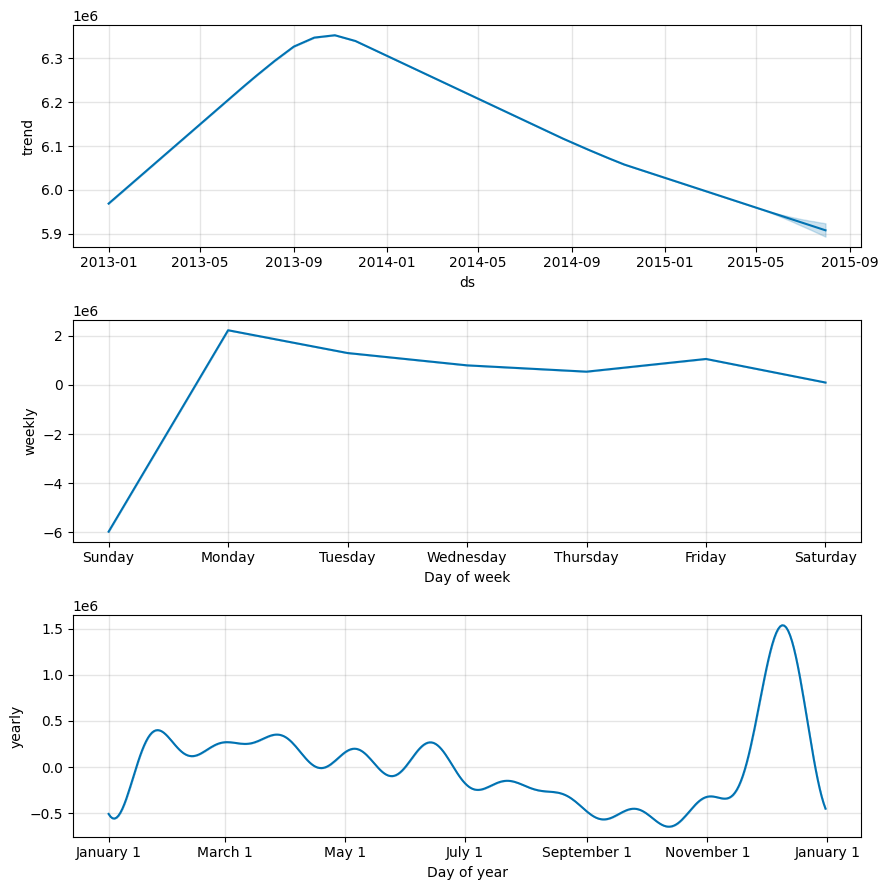

In [10]:
# ============================================================
# SECTION 10: COMPONENTS
# ============================================================

model.plot_components(
    forecast
)

plt.show()